In [3]:
import pandas as pd
import numpy as np
df=pd.read_csv(r"C:\Users\Acer\Desktop\Data_Science_Projects\Clustering\DBSCAN\data\weather-stations20140101-20141231.csv")
print(df.head())
print(df.shape)

                 Stn_Name     Lat     Long Prov   Tm  DwTm    D    Tx  DwTx  \
0               CHEMAINUS  48.935 -123.742   BC  8.2   0.0  NaN  13.5   0.0   
1  COWICHAN LAKE FORESTRY  48.824 -124.133   BC  7.0   0.0  3.0  15.0   0.0   
2           LAKE COWICHAN  48.829 -124.052   BC  6.8  13.0  2.8  16.0   9.0   
3        DISCOVERY ISLAND  48.425 -123.226   BC  NaN   NaN  NaN  12.5   0.0   
4     DUNCAN KELVIN CREEK  48.735 -123.728   BC  7.7   2.0  3.4  14.5   2.0   

    Tn  ...  DwP    P%N  S_G    Pd  BS  DwBS  BS%    HDD  CDD   Stn_No  
0  1.0  ...  0.0    NaN  0.0  12.0 NaN   NaN  NaN  273.3  0.0  1011500  
1 -3.0  ...  0.0  104.0  0.0  12.0 NaN   NaN  NaN  307.0  0.0  1012040  
2 -2.5  ...  9.0    NaN  NaN  11.0 NaN   NaN  NaN  168.1  0.0  1012055  
3  NaN  ...  NaN    NaN  NaN   NaN NaN   NaN  NaN    NaN  NaN  1012475  
4 -1.0  ...  2.0    NaN  NaN  11.0 NaN   NaN  NaN  267.7  0.0  1012573  

[5 rows x 25 columns]
(1341, 25)


In [4]:
X=df.select_dtypes(include=[np.number])
X=X.loc[:,X.notna().any()]
print(X.shape)

(1341, 19)


In [5]:
X=X.fillna(X.mean())
print(X.shape)

(1341, 19)


In [7]:
#Scale DAta
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
X_scaled=scaler.fit_transform(X)
print(X_scaled.shape)

(1341, 19)


In [18]:
#Apply DBSCAN
from sklearn.cluster import DBSCAN
db=DBSCAN(eps=2.5,min_samples=5)
labels=db.fit_predict(X_scaled)
print(np.unique(labels))

[-1  0  1  2  3  4]


In [19]:
#Check Cluster Count
unique,counts=np.unique(labels,return_counts=True)
print(dict(zip(unique,counts)))

{np.int64(-1): np.int64(108), np.int64(0): np.int64(1204), np.int64(1): np.int64(6), np.int64(2): np.int64(6), np.int64(3): np.int64(11), np.int64(4): np.int64(6)}


In [23]:
noise_points=(labels==-1)
print("No. of noise points : ",noise_points.sum())

No. of noise points :  108


In [24]:
noise_data=df[labels==-1]
print(noise_data.head())
print(noise_data.shape)

                    Stn_Name     Lat     Long Prov   Tm  DwTm    D    Tx  \
2              LAKE COWICHAN  48.829 -124.052   BC  6.8  13.0  2.8  16.0   
15      SAANICHTON MT NEWTON  48.598 -123.427   BC  NaN   NaN  NaN   NaN   
24  VICTORIA HIGHLANDS NORTH  48.538 -123.501   BC  8.1  14.0  NaN  13.3   
34   CORTES ISLAND TIBER BAY  50.071 -124.949   BC  8.5  14.0  NaN  14.4   
42                MYRA CREEK  49.576 -125.606   BC  5.8   4.0  NaN  12.0   

    DwTx   Tn  ...   DwP  P%N  S_G    Pd  BS  DwBS  BS%    HDD  CDD   Stn_No  
2    9.0 -2.5  ...   9.0  NaN  NaN  11.0 NaN   NaN  NaN  168.1  0.0  1012055  
15   NaN  NaN  ...  21.0  NaN  NaN   7.0 NaN   NaN  NaN    NaN  NaN  1016RM0  
24  13.0  1.8  ...  13.0  NaN  NaN  14.0 NaN   NaN  NaN  139.3  0.0  1018618  
34  14.0 -1.5  ...  14.0  NaN  0.0  12.0 NaN   NaN  NaN  132.8  0.0  1021960  
42   2.0 -1.5  ...   2.0  NaN  0.0  15.0 NaN   NaN  NaN  292.0  0.0  1025254  

[5 rows x 25 columns]
(108, 25)


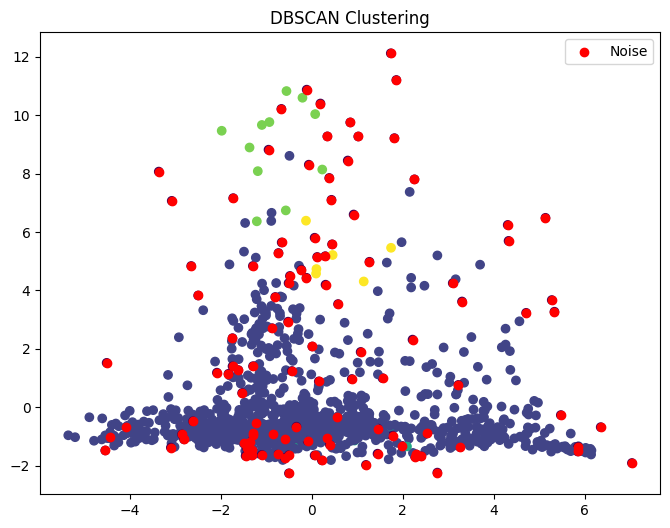

In [21]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
pca=PCA(n_components=2)
X_pca=pca.fit_transform(X_scaled)
plt.figure(figsize=(8,6))
plt.scatter(X_pca[:,0],X_pca[:,1],c=labels)
plt.scatter(X_pca[labels==-1,0],
            X_pca[labels==-1,1],
            c='red',
            label='Noise')
plt.legend()
plt.title('DBSCAN Clustering')
plt.show()